# Mixture of Mixture of Gaussians Example

In [19]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import matplotlib
import scipy
from scipy.special import softmax
from scipy.special import logsumexp
from copy import copy
from sklearn.preprocessing import KernelCenterer

#import code to generate data and do clustNP
from sample_distributions import pair_sample_mixture_of_GMs
from NDIGO import gauss_kernal_mat, proj_simplex, linear_kernel_mat

# Set Parameters

In [20]:
np.random.seed(123)

n = 150 # number of total paired samples
nhold = 100
ntest = 100
M = 2   # true number of mixture components for our KDE
Mprime = 2 #1
d = 1   # ambient dimension 

#w_outer = np.random.rand(M,) # true KDE mixture proportions
w_outer = np.ones((M,))
w_outer *= 1/np.sum(w_outer)
w_inner = np.ones((M,1))
#mus = 2*np.random.randn(1, d, M) # true means for each mixture distribution
mus = np.ones((1, d, M))
#mus[0,0,0] = -2
sigmas = np.ones((1,d,d,M))


# noise_sd = 1

# Generate Data

In [21]:
X, component_ids, pair_ids = pair_sample_mixture_of_GMs(mus, sigmas, w_outer, w_inner, n=n)
Xh, cid_h, pid_h = pair_sample_mixture_of_GMs(mus, sigmas, w_outer, w_inner, n=nhold)
Xte, cid_te, pid_te = pair_sample_mixture_of_GMs(mus, sigmas, w_outer, w_inner, n=ntest)
w_outer

X = np.random.uniform(0,3,(2*n,1)) #just reuse component ids since all are coming from the same distribution

### Plot Pairs as endpoints of line segments

Text(0.5, 0, 'x')

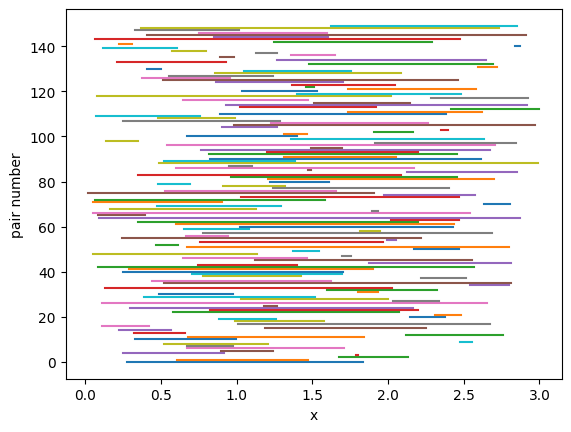

In [22]:
for i in range(n):
    pair = X[pair_ids==i]
    plt.plot(pair, [i,i])
plt.ylabel("pair number")
plt.xlabel("x")

# Generate func vals

# Nonlinear

In [23]:
noise_sd_0 = 1.5
noise_sd_1 = .3

Y = np.ndarray((2*n,1))
Y[(component_ids==0)] = X[component_ids==0]**2 
Y[(component_ids==1)] = -X[component_ids==1]**2
Ytrue = copy(Y)
# Y = Y + np.random.normal(0, noise_sd, Y.shape)

noise_sd = np.ndarray((2*n,1))
noise_sd[(component_ids==0)] = noise_sd_0
noise_sd[(component_ids==1)] = noise_sd_1

Y = Y + np.random.normal(0, noise_sd, Y.shape)

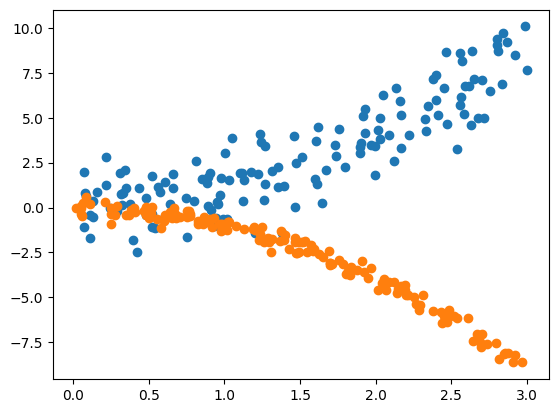

In [24]:
plt.scatter(X[component_ids==0],Y[component_ids==0])
plt.scatter(X[component_ids==1],Y[component_ids==1])
idx = np.argsort(X.flatten())
X_sorted = X.flatten()[idx]
Y_sorted = Y.flatten()[idx]
#plt.plot(X_sorted.flatten(), Y_sorted.flatten(), color='r')

# EM

In [25]:
def lstsq_nesterov(X, Y, alpha0, maxiter=2000):
    Y = Y.flatten()
    ss = 1/np.linalg.norm(X, ord='fro')**2
    alpha = alpha0
    z = alpha0
    gamma = 1
    XtX = X.T@X
    XtY = X.T@Y
    for i in range(maxiter):
        alpha_old = alpha
        alpha = z + ss*(XtY-XtX@z)
        gamma = (np.sqrt(4*gamma**2 + gamma**4) - gamma**2)*0.5
        beta = gamma*(1-1/gamma)
        z = alpha + beta*(alpha - alpha_old)
    return alpha  

In [26]:
def compute_responsibilities(x, Y, w, K, A, sigmas, M):
    
    n2 = x.shape[0] # total data points = 2*number pairs n
    
    assert n2 % 2 == 0, "n must be even for pairing"


    log_probs = []

    # --- compute per-model log probs ---
    for im in range(M):
        mu = K@A[:,im]
        Delta = (Y.squeeze() - mu) ** 2
        print("shape Y", np.shape(Y))
        print("shape mu", np.shape(mu))
        print("shape Delta", np.shape(Delta))
        
        log_likelihood = -Delta / (2 * sigmas[im]) - .5 * np.log(sigmas[im])

        log_prior = np.log(w[im])
        
        log_probs.append(log_likelihood.squeeze())
        print("shape log_probs", np.shape(log_probs))

    # shape: (n2, M)
    log_probs = np.stack(log_probs, axis=1)
    print("shape log_probs 2", np.shape(log_probs))

    # group the pairs
    log_likelihood_pairs = log_probs.reshape(n2 // 2, 2, M)
    print("shape log_probs_pairs", np.shape(log_likelihood_pairs))

    # sum within each pair (correct probabilistically)
    log_likelihood_pairwise = np.sum(log_likelihood_pairs, axis=1)  # (n2/2, M)

    log_probs_pairwise = log_likelihood_pairwise + log_prior

    # compute responsibilities at pair level
    gamma_pairwise = softmax(log_probs_pairwise, axis=1)  # (n2/2, M)

    # expand back so each pair shares gamma
    gamma = gamma_pairwise.repeat(2, axis=0)  # (n2, M)

    return gamma


In [27]:
def compute_objective(M, Y, K, A, w, sigmas, lam=1e-5, eps=1e-8):
    """
    Penalized negative observed log-likelihood for paired data.

    sigmas[m] is assumed to be variance, not standard deviation.
    """
    Yv = Y.squeeze()
    n2 = len(Yv)
    n = n2 // 2
    M = M

    Mu = K @ A                         # shape: (2*n, M)
    Delta = (Yv[:, None] - Mu) ** 2    # shape: (2*n, M)

    log_pair = np.zeros((n, M))

    for m in range(M):
        sigma2_m = sigmas[m] + eps

        residual_sum = Delta[0::2, m] + Delta[1::2, m]

        log_pair[:, m] = (
            np.log(w[m])
            - np.log(2 * np.pi)
            - np.log(sigma2_m)
            - residual_sum / (2 * sigma2_m)
        )

    loglik = np.sum(logsumexp(log_pair, axis=1))

    penalty = 0.0
    for m in range(M):
        penalty += A[:, m].T @ K @ A[:, m]

    objective = -loglik + lam * penalty

    return objective

In [28]:
# kern_width = 0.8

# #K = linear_kernel_mat(X,X)
# K = gauss_kernal_mat(X,X,sigma=kern_width)
# # transformer = KernelCentere
# #r().fit(K)
# # K = transformer.transform(K)
# w, A = scipy.sparse.linalg.eigs(K, k=M)
# # w = np.real(w)
# # w = w/np.sum(w)
# w = np.ones(M) / M
# A = np.real(A)
# sigmas = np.ones(M)
# s1 = sigmas[0]*np.ones(2*n)
# s2 = sigmas[1]*np.ones(2*n)
# sigmas_matrix = np.column_stack((s1,s2))

# maxiter = 50

# R = np.zeros((n,M))

# from scipy.special import logsumexp
# import numpy as np

# Yv = Y.squeeze()          # shape: (2*n,)
# n2 = Yv.shape[0]
# assert n2 == 2*n

# maxiter = 50
# eps = 1e-8

def run_kernel_em_once(X, Y, M=2, kern_width=0.8, maxiter=30, lam=1e-5, seed=None):
    if seed is not None:
        np.random.seed(seed)

    Yv = Y.squeeze()
    n2 = X.shape[0]
    assert n2 % 2 == 0
    n = n2 // 2

    K = gauss_kernal_mat(X, X, sigma=kern_width)

    # initialize A
    # eigvals, A = scipy.sparse.linalg.eigs(K, k=M)
    # A = np.real(A)

    # randomize/sign-jitter A a bit so trials differ
    # A = A + 0.01 * np.random.randn(*A.shape)
    A = np.random.randn(*K.shape)

    # initialize mixture weights and variances
    w = np.ones(M) / M
    sigmas = np.ones(M)

    eps = 1e-8

    objective_trace = []

    for it in range(maxiter):
        # -------------------------
        # E-step
        # -------------------------
        Mu = K @ A                         # shape: (2*n, M)
        Delta = (Yv[:, None] - Mu) ** 2    # shape: (2*n, M)

        log_pair = np.zeros((n, M))

        for m in range(M):
            residual_sum = Delta[0::2, m] + Delta[1::2, m]

            log_pair[:, m] = (
                np.log(w[m]) # + eps
                - np.log(sigmas[m]) # + eps
                - residual_sum / (2 * (sigmas[m])) # + eps
            )

        R_pair = np.exp(log_pair - logsumexp(log_pair, axis=1, keepdims=True))

        # observation-level responsibilities
        R_obs = np.repeat(R_pair, 2, axis=0)

        # -------------------------
        # M-step
        # -------------------------
        w = R_pair.mean(axis=0)

        for m in range(M):
            ### with penalty
            Rm = R_obs[:, m]

            W_K = Rm[:, None] * K
            W_Y = Rm * Yv

            A[:, m] = np.linalg.solve(
                W_K + lam * np.eye(K.shape[0]),
                W_Y
            )

            resid = Yv - K @ A[:, m]
            sigmas[m] = np.sum(Rm * resid**2) / np.sum(Rm)

            ### without penalty
            # Rm = R_obs[:, m]                  # shape: (2*n,)
            # sqrt_Rm = np.sqrt(Rm + eps) # +eps
    
            # K_weighted = K * sqrt_Rm[:, None]
            # Y_weighted = Yv * sqrt_Rm
    
            # # Weighted least squares update for A[:, m]
            # A[:, m] = lstsq_nesterov(K_weighted, Y_weighted, A[:, m])
            # # Or:
            # # A[:, m] = np.linalg.lstsq(K_weighted, Y_weighted, rcond=None)[0]
    
            # resid = Yv - K @ A[:, m]
    
            # sigmas[m] = np.sum(Rm * resid**2) / np.sum(Rm)

        # -------------------------
        # Record objective
        # -------------------------
        objective_trace.append(
            compute_objective(M, Y, K, A, w, sigmas, lam=lam)
        )

    return sigmas, w, A, np.array(objective_trace)

# Check out the results

In [ ]:
n_trials = 200
maxiter = 30 # do more than 100

sigma_pairs = np.zeros((n_trials, 2))
weight_pairs = np.zeros((n_trials, 2))

final_objectives = np.zeros(n_trials)
objective_traces = np.zeros((n_trials, maxiter))


for trial in range(n_trials):
    sigmas_hat, w_hat, A_hat, obj_trace = run_kernel_em_once(
        X,
        Y,
        M=2,
        kern_width=.8,
        maxiter=maxiter,
        lam=1e-3,
        seed=trial
    )
    sigma_pairs[trial, :] = np.sort(sigmas_hat)
    # sigma_pairs[trial, :] = sigmas_hat
    weight_pairs[trial, :] = w_hat
    objective_traces[trial, :] = obj_trace
    final_objectives[trial] = obj_trace[-1]
    

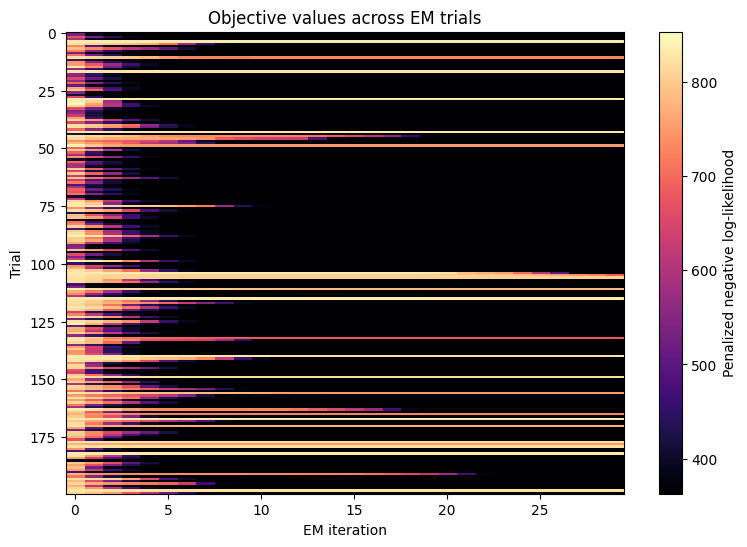

In [30]:
# lower objective = better

plt.figure(figsize=(9, 6))

plt.imshow(
    objective_traces,
    aspect="auto",
    cmap="magma",
    interpolation="nearest"
)

plt.colorbar(label="Penalized negative log-likelihood")
plt.xlabel("EM iteration")
plt.ylabel("Trial")
plt.title("Objective values across EM trials")

plt.show()

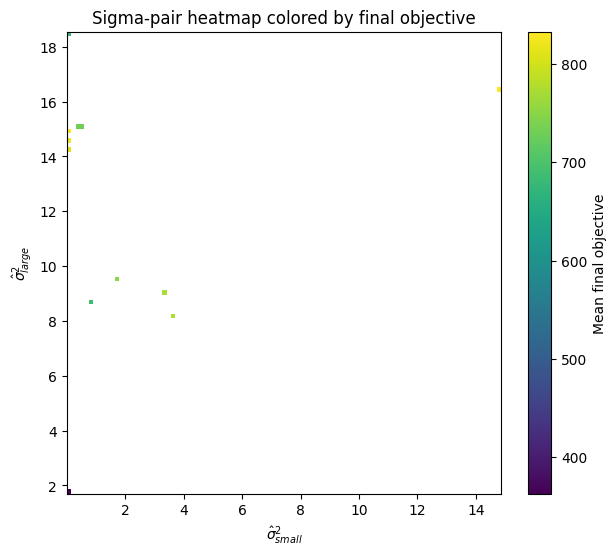

In [31]:
from scipy.stats import binned_statistic_2d

stat, xedges, yedges, _ = binned_statistic_2d(
    sigma_pairs[:, 0],
    sigma_pairs[:, 1],
    final_objectives,
    statistic="mean",
    bins=100
)

plt.figure(figsize=(7, 6))

plt.pcolormesh(
    xedges,
    yedges,
    stat.T,
    cmap="viridis",
    shading="auto"
)

plt.colorbar(label="Mean final objective")
plt.xlabel(r"$\hat{\sigma}_{small}^2$")
plt.ylabel(r"$\hat{\sigma}_{large}^2$")
plt.title("Sigma-pair heatmap colored by final objective")

# plt.xlim(0, 2.0)
# plt.ylim(0, 2.0)

plt.show()

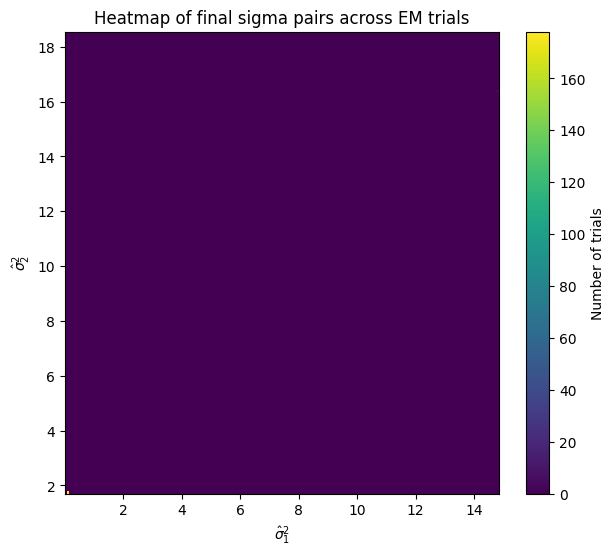

In [32]:
plt.figure(figsize=(7, 6))

h = plt.hist2d(
    sigma_pairs[:, 0],
    sigma_pairs[:, 1],
    bins=200,
    cmap="viridis"
)

plt.colorbar(label="Number of trials")
plt.xlabel(r"$\hat{\sigma}_1^2$")
plt.ylabel(r"$\hat{\sigma}_2^2$")
plt.title("Heatmap of final sigma pairs across EM trials")
# plt.xlim(0, 2.0)
# plt.ylim(0, 2.0)

plt.show()

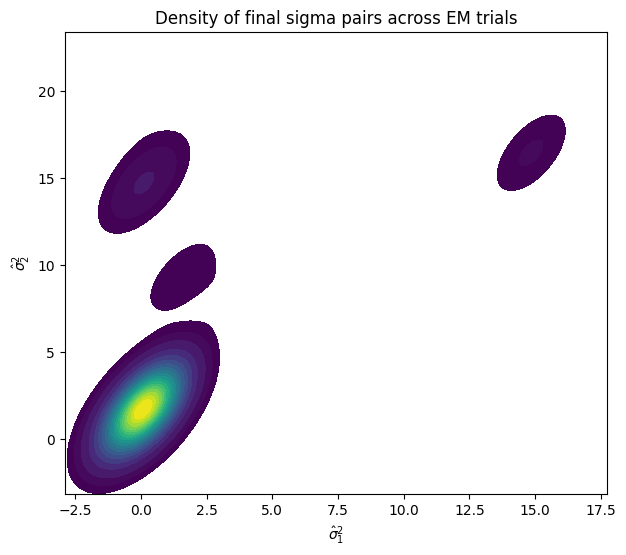

In [33]:
plt.figure(figsize=(7, 6))

sns.kdeplot(
    x=sigma_pairs[:, 0],
    y=sigma_pairs[:, 1],
    fill=True,
    cmap="viridis",
    levels=20
)

plt.xlabel(r"$\hat{\sigma}_1^2$")
plt.ylabel(r"$\hat{\sigma}_2^2$")
plt.title("Density of final sigma pairs across EM trials")
# plt.ylim(0.0,1.0)

plt.show()

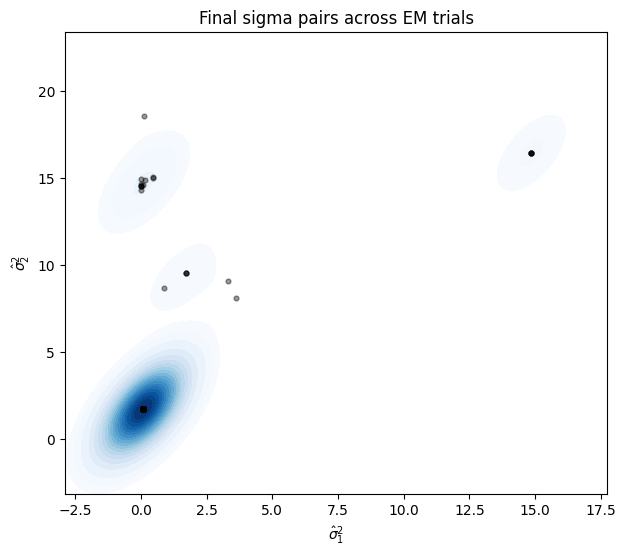

In [34]:
plt.figure(figsize=(7, 6))

sns.kdeplot(
    x=sigma_pairs[:, 0],
    y=sigma_pairs[:, 1],
    fill=True,
    cmap="Blues",
    levels=20
)

plt.scatter(
    sigma_pairs[:, 0],
    sigma_pairs[:, 1],
    s=12,
    c="black",
    alpha=0.4
)

plt.xlabel(r"$\hat{\sigma}_1^2$")
plt.ylabel(r"$\hat{\sigma}_2^2$")
plt.title("Final sigma pairs across EM trials")

plt.show()

In [35]:
print(sigma_pairs)

[[8.16206623e-02 1.69872578e+00]
 [8.16206623e-02 1.69872578e+00]
 [8.16206623e-02 1.69872578e+00]
 [8.16206623e-02 1.69872578e+00]
 [1.48544234e+01 1.64350690e+01]
 [8.16206623e-02 1.69872578e+00]
 [8.16206623e-02 1.69872578e+00]
 [8.16206623e-02 1.69872578e+00]
 [8.16206623e-02 1.69872578e+00]
 [8.16206623e-02 1.69872578e+00]
 [8.16206623e-02 1.69872578e+00]
 [4.40660064e-01 1.50208969e+01]
 [8.16206623e-02 1.69872578e+00]
 [8.16206623e-02 1.69872578e+00]
 [8.16206623e-02 1.69872578e+00]
 [8.16206623e-02 1.69872578e+00]
 [8.16206623e-02 1.69872578e+00]
 [1.89429233e-04 1.49321583e+01]
 [8.16206623e-02 1.69872578e+00]
 [8.16206623e-02 1.69872578e+00]
 [8.16206623e-02 1.69872578e+00]
 [8.16206623e-02 1.69872578e+00]
 [8.16206623e-02 1.69872578e+00]
 [8.16206623e-02 1.69872578e+00]
 [8.16206623e-02 1.69872578e+00]
 [8.16206623e-02 1.69872578e+00]
 [8.16206623e-02 1.69872578e+00]
 [8.16206623e-02 1.69872578e+00]
 [8.16206623e-02 1.69872578e+00]
 [1.41652347e-01 1.48544234e+01]
 [8.162066

In [36]:
Y_hat = np.zeros((2*n,M))
for j in range(M):
        #Rm = np.repeat(R[:,j]**0.5,2,axis=0)
        #Y_hat[:,j] = (K.T*Rm).T@A[:,j]
        Y_hat[:,j] = K@A[:,j]

NameError: name 'K' is not defined

Prop Correct Mixture Assignment = 0.5266666666666666


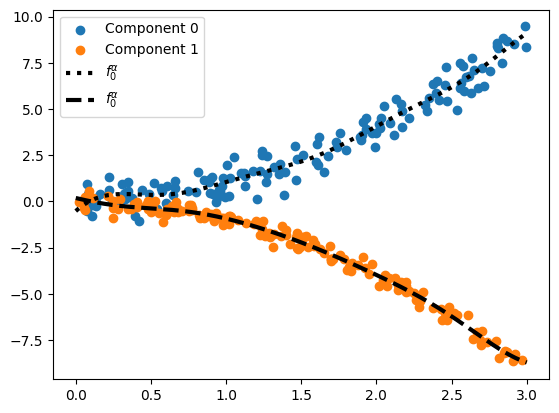

In [ ]:
plt.scatter(X[component_ids==0],Y[component_ids==0], label="Component 0")
plt.scatter(X[component_ids==1],Y[component_ids==1], label="Component 1")

xx = np.reshape(np.linspace(0,3,1000), (1000,1))
Ktest = gauss_kernal_mat(xx,X,sigma=kern_width)
Yhat = Ktest@A
plt.plot(xx, Yhat[:,0], 'k:', linewidth=3, label=r"$f_0^\alpha$")
plt.plot(xx, Yhat[:,1], 'k--', linewidth=3, label=r"$f_0^\alpha$")

Rdouble = np.repeat(R,2,axis=0)
correct_assignments = max(sum(component_ids==np.argmax(Rdouble,axis=1) ), 
                          sum((1-component_ids)==np.argmax(Rdouble,axis=1)) 
                         ) / (2*n)
print(f"Prop Correct Mixture Assignment = {correct_assignments}")

plt.rcParams.update({'font.size': 10})
plt.legend()

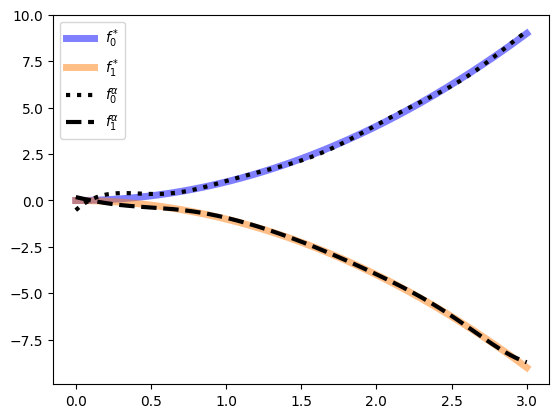

In [ ]:
plt.plot(xx, xx**2, 'b', linewidth=5, label="$f_0^*$", alpha=0.5)
plt.plot(xx, -xx**2, 'tab:orange', linewidth=5, label="$f_1^*$", alpha=0.5)
plt.plot(xx, Yhat[:,0], 'k:', linewidth=3, label=r"$f_0^\alpha$")
plt.plot(xx, Yhat[:,1], 'k--', linewidth=3, label=r"$f_1^\alpha$")
plt.rcParams.update({'font.size': 10})
plt.legend()


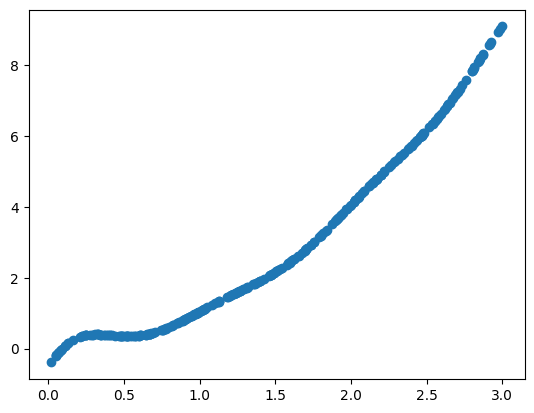

In [ ]:
Rdouble = np.repeat(R,2,axis=0)
plt.scatter(X[np.argmax(Rdouble,axis=1)==0],Y_hat[np.argmax(Rdouble,axis=1)==0,0])
plt.scatter(X[np.argmax(Rdouble,axis=1)==1],Y_hat[np.argmax(Rdouble,axis=1)==1,1])
idx = np.argsort(X.flatten())
X_sorted = X.flatten()[idx]
Y_sorted = Y.flatten()[idx]
#plt.plot(X_sorted.flatten(), Y_sorted.flatten(), color='r')

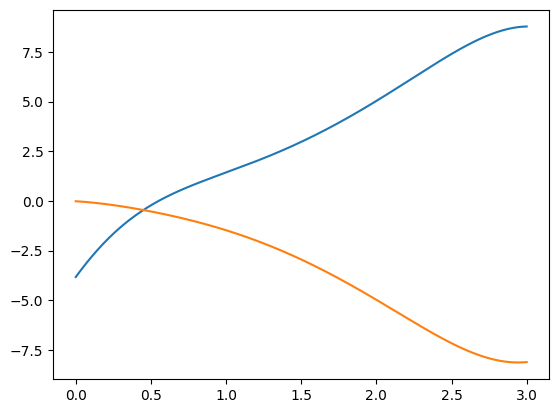

In [ ]:
xx = np.reshape(np.linspace(0,3,1000), (1000,1))
Ktest = gauss_kernal_mat(xx,X,sigma=0.95)
Yhat = Ktest@A
plt.plot(xx, Yhat[:,0])
plt.plot(xx, Yhat[:,1])